Setup and Imports

In [ ]:
#!pip install -U tensorflow tensorflow-datasets scikit-learn

In [2]:
import os, random, math
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, optimizers, metrics, regularizers, callbacks
from tensorflow.keras.utils import plot_model

from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

# Reproducibility
SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
tf.config.experimental.enable_op_determinism()

# Pretty plots
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True

print("TensorFlow:", tf.__version__)
print("TFDS:", tfds.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
TFDS: 4.9.9
GPU: []


Load IMDB & Make Splits

Why: Use a standard dataset with a clean train/test split. We also need a validation set to choose hyperparameters and a classification threshold without touching the test set.

How: Load IMDB via TFDS, then carve 5k reviews from the 25k train set for validation.

In [3]:
# Load IMDB: 25k train, 25k test (labels: 0=neg, 1=pos)
raw_train, raw_test = tfds.load(
    "imdb_reviews",
    split=["train", "test"],
    as_supervised=True
)

# Shuffle and split: 20k train, 5k val
raw_train = raw_train.shuffle(25_000, seed=SEED)
train_size = 20_000
ds_train = raw_train.take(train_size)
ds_val   = raw_train.skip(train_size)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.HBRPOI_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.HBRPOI_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.HBRPOI_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


**Quick EDA (Actionable)**

Why: We only need decisions that affect preprocessing: sequence length, whether class weights are needed, and to confirm data looks sane.

How: Sample a subset, check class balance and review length distribution to pick SEQLEN.

Class counts (sample): Counter({np.int64(0): 2520, np.int64(1): 2480})
Mean len: 234.6 | Median: 175 | 95th pct: 596


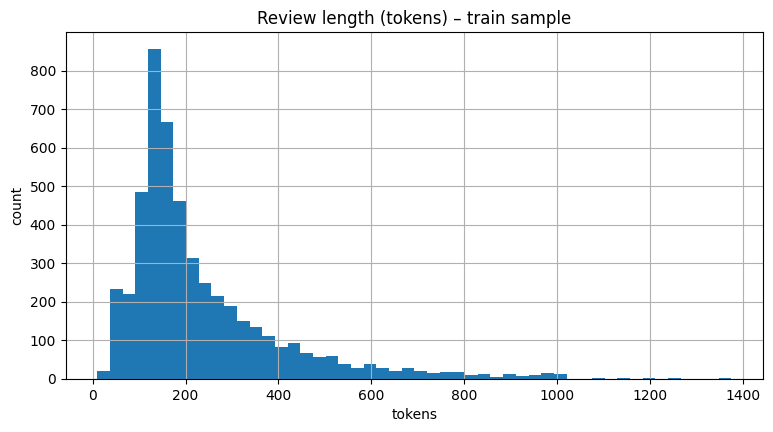

In [4]:
SAMPLE_FOR_EDA = 5000

def take_text_label(ds, n):
    xs, ys = [], []
    for x, y in ds.take(n):
        xs.append(x.numpy().decode("utf-8"))
        ys.append(int(y.numpy()))
    return xs, np.array(ys)

texts_eda_train, labels_eda_train = take_text_label(ds_train, SAMPLE_FOR_EDA)

# Class balance (IMDB is roughly balanced)
import collections
cnt = collections.Counter(labels_eda_train)
print("Class counts (sample):", cnt)

# Length distribution → helps choose max sequence length
token_lens = [len(t.split()) for t in texts_eda_train]
print(f"Mean len: {np.mean(token_lens):.1f} | Median: {np.median(token_lens):.0f} | 95th pct: {np.percentile(token_lens,95):.0f}")

plt.figure()
plt.hist(token_lens, bins=50)
plt.title("Review length (tokens) – train sample")
plt.xlabel("tokens"); plt.ylabel("count")
plt.show()

# Decisions from EDA:
VOCAB_SIZE = 20_000   # limit vocabulary size to reduce memory / overfitting
SEQLEN     = 250      # covers most reviews without too much padding
BATCH      = 128
AUTOTUNE   = tf.data.AUTOTUNE


**Insight:**

**Class Balance :** Counter({0: 2520, 1: 2480}) → Nearly perfect balance between negative (0) and positive (1) reviews in the sample.
-> This means we don’t need class weights or resampling — the model can be trained without bias corrections for imbalance.

**Review Length Statistics**
* Mean length: ~235 tokens
* Median length: 175 tokens → half of reviews are shorter than this.
* 95th percentile: 596 tokens → 95% of reviews are ≤ 596 tokens.

**Shape of Distribution**
* The histogram is right-skewed:
* Most reviews are between 100–300 tokens.
* A small number of very long reviews (up to ~1400 tokens) exist, but they’re rare.

**Implication for Model Preprocessing**
Sequence length (SEQLEN) choice:
* If we set SEQLEN = 250, we capture most reviews without excessive padding.
* This matches well with the spike in the histogram around 150–200 tokens.
* Going too high (e.g., 600) means a lot of padding, slowing training and risking overfitting.
* Truncating at 250 tokens will cut some longer reviews, but the trade-off is worth it for performance.

**Summary Insight**
* Dataset is balanced → no need for class weighting.
* Reviews are moderately long; 250–300 tokens is an efficient maxlen.
* Most of the signal for sentiment will be in the first few hundred tokens, so truncation won’t likely hurt accuracy much.

**Cumulative Coverage Plot**

This will help to visually choose the optimal SEQLEN.

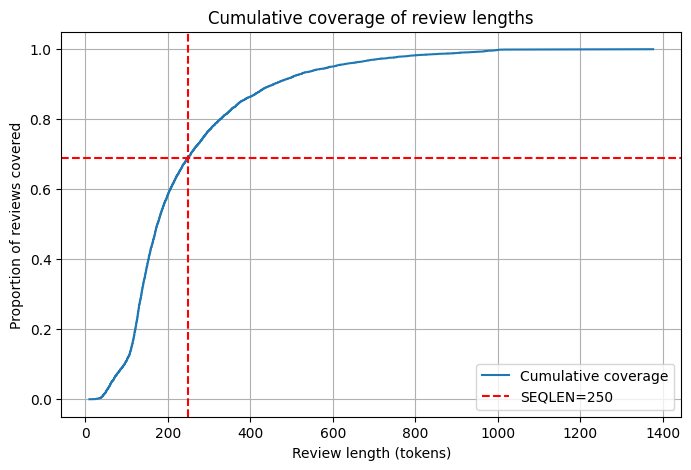

Coverage at 250 tokens: 69.06% of reviews


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# token_lens comes from: token_lens = [len(t.split()) for t in texts_eda_train]
lens_sorted = np.sort(token_lens)
cum_coverage = np.arange(1, len(lens_sorted)+1) / len(lens_sorted)

plt.figure(figsize=(8,5))
plt.plot(lens_sorted, cum_coverage, label="Cumulative coverage")
plt.axvline(250, color="r", linestyle="--", label="SEQLEN=250")
plt.axhline(cum_coverage[np.searchsorted(lens_sorted, 250)],
            color="r", linestyle="--")

plt.title("Cumulative coverage of review lengths")
plt.xlabel("Review length (tokens)")
plt.ylabel("Proportion of reviews covered")
plt.legend()
plt.grid(True)
plt.show()

# Print coverage percentage for chosen SEQLEN
coverage_at_250 = cum_coverage[np.searchsorted(lens_sorted, 250)]
print(f"Coverage at 250 tokens: {coverage_at_250*100:.2f}% of reviews")


**Insight**

**Coverage at SEQLEN = 250**
* The red crosshair shows that 250 tokens covers ≈ 69% of all reviews without truncation.
* This means ~31% of reviews are longer than 250 tokens and will be truncated if we fix the maximum length to 250.

**Trade-off Between Coverage and Efficiency**
* Increasing SEQLEN increases coverage but also:
* More padding for shorter reviews → wasted computation.
* More model parameters and longer training time.

**Choosing an Optimal SEQLEN**
* If the goal is efficiency and faster training, SEQLEN = 250 is reasonable — it keeps sequences short while capturing most of the sentiment-bearing content.
* If the goal is maximum coverage, SEQLEN ≈ 500–600 might be better, but training will be slower and require more memory.

**Practical NLP Insight**
* For IMDB sentiment, the sentiment is usually clear within the first few sentences.
* Truncating longer reviews often has minimal impact on accuracy because additional content tends to repeat or reinforce earlier sentiment cues.

In [6]:
# Possible sequence lengths check
seq_lengths = [250, 300, 400, 500, 600]

# Function to get coverage %
def coverage_at_len(length):
    idx = np.searchsorted(lens_sorted, length, side='right')
    return cum_coverage[idx-1] * 100

# Build table
print(f"{'SEQLEN':>8} | {'Coverage (%)':>12}")
print("-" * 25)
for sl in seq_lengths:
    print(f"{sl:>8} | {coverage_at_len(sl):>12.2f}")


  SEQLEN | Coverage (%)
-------------------------
     250 |        69.20
     300 |        76.90
     400 |        86.46
     500 |        91.94
     600 |        95.06


We chose SEQLEN=250 to balance training speed with ~69% non-truncated coverage, given that sentiment is usually expressed early in the review

**Preprocessing with Custom Standardizer**

Why: We want consistent text normalization (lowercase, strip <br>, URLs, compress spaces) without deleting sentiment-bearing cues like ! and ?.

How: Use TextVectorization with a custom standardize function, cap the vocab, and fix the sequence length (padding/truncation).

In [7]:
def custom_standardize(x):
    # lowercase
    x = tf.strings.lower(x)
    # remove common IMDB HTML line breaks
    x = tf.strings.regex_replace(x, r"<br\s*/?>", " ")
    # remove URLs
    x = tf.strings.regex_replace(x, r"http\S+|www\.\S+", " ")
    # keep ! and ? (sentiment-y); strip most other non-alnum punctuation
    x = tf.strings.regex_replace(x, r"[^a-z0-9!?'\s]", " ")
    # compress whitespace
    x = tf.strings.regex_replace(x, r"\s+", " ")
    return tf.strings.strip(x)

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=SEQLEN,
    standardize=custom_standardize,
    split="whitespace"
)

# Adapt on training text only (prevents information leakage)
vectorizer.adapt(ds_train.map(lambda x, y: x))

def vectorize_batch(text, label):
    text = tf.reshape(text, (-1,))  # ensure rank-1
    return vectorizer(text), label

train = (
    ds_train
    .batch(BATCH)
    .map(vectorize_batch, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

val = (
    ds_val
    .batch(BATCH)
    .map(vectorize_batch, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

test = (
    raw_test
    .batch(BATCH)
    .map(vectorize_batch, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)


**Model Architecture**

Why: A Bidirectional GRU is a strong, efficient baseline for sentiment tasks: it captures context from both directions with fewer parameters than LSTM. SpatialDropout1D regularizes embeddings, and mask_zero=True avoids learning from padding.

How: Embedding → SpatialDropout → BiGRU → Dropout → Dense(64, ReLU) → Sigmoid. Optimize with Adam, monitor accuracy and AUC.

In [8]:
def build_model(
    vocab_size=VOCAB_SIZE,
    seq_len=SEQLEN,
    embedding_dim=128,
    rnn_units=96,
    dropout=0.4,
    spatial_dropout=0.3,
    lr=1e-3
):
    inputs = tf.keras.Input(shape=(seq_len,), dtype=tf.int32)
    x = layers.Embedding(vocab_size, embedding_dim, mask_zero=True)(inputs)
    x = layers.SpatialDropout1D(spatial_dropout)(x)
    x = layers.Bidirectional(layers.GRU(rnn_units))(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=[metrics.BinaryAccuracy(name="accuracy"), metrics.AUC(name="auc")]
    )
    return model

model = build_model()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 250, 128)  │  2,560,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 250, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 250)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 192)       │    130,176 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 192)       │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,702,593 (10.31 MB)

 Trainable params: 2,702,593 (10.31 MB)

 Non-trainable params: 0 (0.00 B)

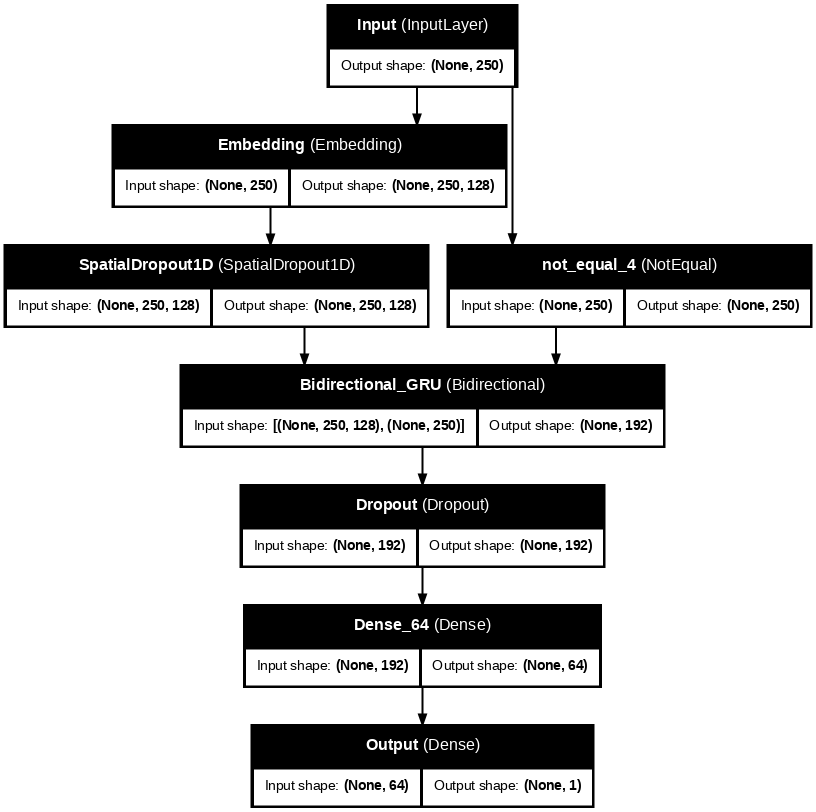

In [12]:
def build_model_for_plot(vocab_size=20000, seq_len=250, embedding_dim=128, rnn_units=96, dropout=0.4, spatial_dropout=0.3):
    inputs = layers.Input(shape=(seq_len,), dtype="int32", name="Input")
    x = layers.Embedding(vocab_size, embedding_dim, mask_zero=True, name="Embedding")(inputs)
    x = layers.SpatialDropout1D(spatial_dropout, name="SpatialDropout1D")(x)
    x = layers.Bidirectional(layers.GRU(rnn_units), name="Bidirectional_GRU")(x)
    x = layers.Dropout(dropout, name="Dropout")(x)
    x = layers.Dense(64, activation="relu", name="Dense_64")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="Output")(x)
    model = models.Model(inputs, outputs, name="BiGRU_Sentiment_Model")
    return model

# Build and plot model (vertical, smaller size)
plot_model_model = build_model_for_plot()
plot_model(
    plot_model_model,
    to_file="model_architecture_vertical.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=72,         # Lower DPI → smaller image
    rankdir="TB"    # Top-to-Bottom layout
)


**Training Strategy**

Why: We want to stop before overfitting and keep the best weights.

How: Use EarlyStopping (patience=2, restore best) and ModelCheckpoint (save best by val_loss). Train for up to 10 epochs; early stopping usually halts sooner.

In [13]:
early = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=2, restore_best_weights=True
)
ckpt_path = "best_bigru.keras"
ckpt = tf.keras.callbacks.ModelCheckpoint(
    ckpt_path, monitor="val_loss", save_best_only=True
)

history = model.fit(
    train,
    validation_data=val,
    epochs=5,
    callbacks=[early, ckpt],
    verbose=1
)


Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.6093 - auc: 0.6660 - loss: 0.6243 - val_accuracy: 0.8984 - val_auc: 0.9602 - val_loss: 0.2662
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - accuracy: 0.8806 - auc: 0.9491 - loss: 0.2856 - val_accuracy: 0.9350 - val_auc: 0.9826 - val_loss: 0.1684
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - accuracy: 0.9357 - auc: 0.9797 - loss: 0.1769 - val_accuracy: 0.8928 - val_auc: 0.9874 - val_loss: 0.2585
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.9405 - auc: 0.9849 - loss: 0.1551 - val_accuracy: 0.9504 - val_auc: 0.9893 - val_loss: 0.1333
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step - accuracy: 0.9642 - auc: 0.9941 - loss: 0.0949 - val_accuracy: 0.9674 - val_auc: 0.9937 - val_loss: 0.0916


# **Learning Curves**

* Why: Curves help diagnose under/overfitting.
* How: Plot training/validation loss and accuracy over epochs.

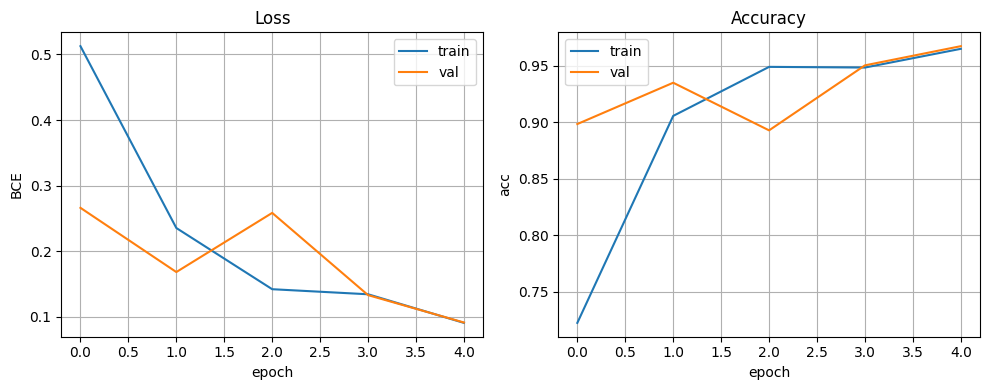

In [15]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss"); plt.xlabel("epoch"); plt.ylabel("BCE"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy"); plt.xlabel("epoch"); plt.ylabel("acc"); plt.legend()
plt.tight_layout()
plt.show()

**Choose Decision Threshold on Validation**

* Why: The default 0.5 isn’t always optimal. We select a threshold that maximizes F1 on the validation set, then freeze it to avoid test leakage.
* Sweep thresholds, compute F1, pick the best.

In [17]:
# Get probabilities on validation set
val_probs, val_labels = [], []
for xb, yb in val:
    val_probs.append(model.predict(xb, verbose=0).ravel())
    val_labels.append(yb.numpy())
val_probs = np.concatenate(val_probs)
val_labels = np.concatenate(val_labels)

# Sweep thresholds to maximize F1
ths = np.linspace(0.3, 0.7, 41)
best_thr, best_f1 = 1, -1  #0.5
for t in ths:
    preds = (val_probs >= t).astype(int)
    _, _, f1, _ = precision_recall_fscore_support(val_labels, preds, average="binary", zero_division=0)
    if f1 > best_f1:
        best_f1, best_thr = f1, t

print(f"Chosen threshold = {best_thr:.3f} (val F1={best_f1:.4f})")


Chosen threshold = 0.350 (val F1=0.9684)


**Final Test Evaluation**

* Why: Only evaluate on the untouched test set once to report final metrics.
* How: Apply the frozen threshold, compute Accuracy/AUC and a full classification report with confusion matrix.

In [18]:
test_probs, test_labels = [], []
for xb, yb in test:
    test_probs.append(model.predict(xb, verbose=0).ravel())
    test_labels.append(yb.numpy())
test_probs = np.concatenate(test_probs)
test_labels = np.concatenate(test_labels)

test_pred = (test_probs >= best_thr).astype(int)

ACC = accuracy_score(test_labels, test_pred)
AUC = roc_auc_score(test_labels, test_probs)
print(f"TEST — ACC: {ACC:.4f} | AUC: {AUC:.4f}")
print(classification_report(test_labels, test_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(test_labels, test_pred))


TEST — ACC: 0.8465 | AUC: 0.9239
              precision    recall  f1-score   support

           0     0.8491    0.8427    0.8459     12500
           1     0.8439    0.8502    0.8471     12500

    accuracy                         0.8465     25000
   macro avg     0.8465    0.8465    0.8465     25000
weighted avg     0.8465    0.8465    0.8465     25000

Confusion matrix:
 [[10534  1966]
 [ 1872 10628]]


**Interpretation**

Train ≈ Val, but both ≫ Test → Model generalizes worse to unseen test data than to validation data.

**Light Error Analysis**

* Why: Understanding which reviews are misclassified helps guide improvements (e.g., longer SEQLEN, different RNN units, pretrained embeddings).

* How: Keep original test texts, show a few false positives/negatives with their predicted probabilities.

In [19]:
# Keep original test texts while predicting
raw_test_batched = raw_test.batch(BATCH)

texts_all, labels_all, probs_all = [], [], []
for xb_text, yb in raw_test_batched:
    texts_all.extend([t.decode("utf-8") for t in xb_text.numpy()])
    labels_all.extend(yb.numpy().tolist())
    xb_vec = vectorizer(xb_text)
    probs_all.extend(model.predict(xb_vec, verbose=0).ravel().tolist())

texts_all = np.array(texts_all)
labels_all = np.array(labels_all)
probs_all  = np.array(probs_all)
pred_all   = (probs_all >= best_thr).astype(int)

# Indices of hardest errors
fp_idx = np.where((pred_all == 1) & (labels_all == 0))[0]  # predicted pos but actually neg
fn_idx = np.where((pred_all == 0) & (labels_all == 1))[0]  # predicted neg but actually pos

def show_examples(idxs, k=5, title=""):
    print(f"\n=== {title} (showing {min(k, len(idxs))} of {len(idxs)}) ===")
    for i in idxs[:k]:
        print(f"[prob={probs_all[i]:.3f} | true={labels_all[i]} | pred={pred_all[i]}]")
        print(texts_all[i][:500].replace("\n"," "))
        print("-"*80)

show_examples(fp_idx, k=5, title="False Positives")
show_examples(fn_idx, k=5, title="False Negatives")



=== False Positives (showing 5 of 1966) ===
[prob=1.000 | true=0 | pred=1]
As long as you keep in mind that the production of this movie was a copyright ploy, and not intended as a serious release, it is actually surprising how not absolutely horrible it is. I even liked the theme music.<br /><br />And if ever a flick cried out for a treatment by Joel (or Mike) and the MST3K Bots, this is it! Watch this with a bunch of smart-ass wise-crackers, and you're in for a good time. Have a brew, butter up some large pretzels, and enjoy.<br /><br />Of course, obtaining a copy re
--------------------------------------------------------------------------------
[prob=0.508 | true=0 | pred=1]
It's so fake! The plot seems like a generic adaptation of the average blaxploitation film. The common themes of blaxploitation like racism, oppression and fighting for the integrity of your community are outlined so simplistically/shallowly. And the jokes aren't even funny! Dolemite does these stand up monolog

**Improvements**


1) Quick architecture switchers (GRU ↔ LSTM, with/without GlobalMaxPool1D)

In [21]:
def build_rnn(
    cell="GRU",              # "GRU" or "LSTM"
    bidirectional=True,      # True/False
    pooled=False,            # use GlobalMaxPool1D over return_sequences
    vocab_size=20000,
    seq_len=250,
    embedding_dim=128,
    rnn_units=96,
    spatial_dropout=0.3,
    dropout=0.4,
    lr=1e-3,
    embedding_layer=None     # supply a custom embedding (e.g., GloVe) or None
):
    RNN = layers.GRU if cell.upper()=="GRU" else layers.LSTM
    inputs = layers.Input(shape=(seq_len,), dtype="int32")
    x = (embedding_layer or layers.Embedding(vocab_size, embedding_dim, mask_zero=True))(inputs)
    x = layers.SpatialDropout1D(spatial_dropout)(x)

    if pooled:
        # return full sequence then pool → smaller & fast
        rnn = RNN(rnn_units, return_sequences=True)
        x = layers.Bidirectional(rnn)(x) if bidirectional else rnn(x)
        x = layers.GlobalMaxPool1D()(x)
    else:
        rnn = RNN(rnn_units)
        x = layers.Bidirectional(rnn)(x) if bidirectional else rnn(x)

    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs, name=f"{'Bi' if bidirectional else ''}{cell}{'_Pooled' if pooled else ''}")
    model.compile(
        optimizer=optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=[metrics.BinaryAccuracy(name="accuracy"), metrics.AUC(name="auc")]
    )
    return model


GRU vs LSTM run (with and without pooling)

In [23]:
configs = [
    dict(cell="GRU",  bidirectional=True,  pooled=False),
    dict(cell="LSTM", bidirectional=True,  pooled=False),
    dict(cell="GRU",  bidirectional=True,  pooled=True),
    dict(cell="LSTM", bidirectional=True,  pooled=True),
]

histories = {}
for cfg in configs:
    print("\n=== Training:", cfg, "===")
    m = build_rnn(**cfg)
    h = m.fit(train, validation_data=val, epochs=5,
              callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
              verbose=1)
    histories[str(cfg)] = (m, h.history)



=== Training: {'cell': 'GRU', 'bidirectional': True, 'pooled': False} ===
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.5921 - auc: 0.6415 - loss: 0.6354 - val_accuracy: 0.8780 - val_auc: 0.9582 - val_loss: 0.2970
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step - accuracy: 0.8768 - auc: 0.9463 - loss: 0.2945 - val_accuracy: 0.8944 - val_auc: 0.9817 - val_loss: 0.2560
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.9290 - auc: 0.9775 - loss: 0.1892 - val_accuracy: 0.9346 - val_auc: 0.9878 - val_loss: 0.1863
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 235s 2s/step - accuracy: 0.9478 - auc: 0.9880 - loss: 0.1369 - val_accuracy: 0.9488 - val_auc: 0.9883 - val_loss: 0.1550
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.9548 - auc: 0.9903 - loss: 0.1205 - val_accuracy: 0.9532 - val_auc: 0.9899 - val_loss: 0.1415

=== Training: {'cell': 'LSTM', 'bidirectional': True, 'pooled': False} ===
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/st

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.6165 - auc: 0.6692 - loss: 0.6360 - val_accuracy: 0.8696 - val_auc: 0.9522 - val_loss: 0.3106
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - accuracy: 0.8596 - auc: 0.9335 - loss: 0.3287 - val_accuracy: 0.9254 - val_auc: 0.9794 - val_loss: 0.2006
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.9186 - auc: 0.9726 - loss: 0.2092 - val_accuracy: 0.9476 - val_auc: 0.9848 - val_loss: 0.1593
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - accuracy: 0.9307 - auc: 0.9806 - loss: 0.1773 - val_accuracy: 0.9472 - val_auc: 0.9884 - val_loss: 0.1490
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.9518 - auc: 0.9890 - loss: 0.1310 - val_accuracy: 0.9650 - val_auc: 0.9906 - val_loss: 0.1105

=== Training: {'cell': 'LSTM', 'bidirectional': True, 'pooled': True} ===
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'global_max_pooling1d_1' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - accuracy: 0.6267 - auc: 0.6925 - loss: 0.6083 - val_accuracy: 0.8736 - val_auc: 0.9588 - val_loss: 0.3338
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.8777 - auc: 0.9449 - loss: 0.2986 - val_accuracy: 0.9006 - val_auc: 0.9769 - val_loss: 0.2833
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.9234 - auc: 0.9718 - loss: 0.2099 - val_accuracy: 0.9454 - val_auc: 0.9835 - val_loss: 0.1627
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 0.9453 - auc: 0.9834 - loss: 0.1580 - val_accuracy: 0.9546 - val_auc: 0.9873 - val_loss: 0.1411
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.9618 - auc: 0.9914 - loss: 0.1109 - val_accuracy: 0.9428 - val_auc: 0.9893 - val_loss: 0.1513


In [24]:
#Test Data Evaluation
# ---- helpers ----
def get_probs_labels(model, dataset):
    probs, labels = [], []
    for xb, yb in dataset:
        probs.append(model.predict(xb, verbose=0).ravel())
        labels.append(yb.numpy())
    return np.concatenate(probs), np.concatenate(labels)

def best_threshold_f1(y_true, y_prob, grid=np.linspace(0.3, 0.7, 41)):
    best_t, best_f1 = 0.35, -1.0
    for t in grid:
        y_pred = (y_prob >= t).astype(int)
        _, _, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="binary", zero_division=0
        )
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

def eval_on_test(model, val_ds, test_ds):
    # 1) pick threshold on validation
    val_prob, val_true = get_probs_labels(model, val_ds)
    thr, val_f1 = best_threshold_f1(val_true, val_prob)

    # 2) evaluate on test with frozen threshold
    test_prob, test_true = get_probs_labels(model, test_ds)
    test_pred = (test_prob >= thr).astype(int)

    acc = accuracy_score(test_true, test_pred)
    auc = roc_auc_score(test_true, test_prob)
    prec, rec, f1, _ = precision_recall_fscore_support(
        test_true, test_pred, average="binary", zero_division=0
    )
    return {
        "thr": thr, "val_f1": val_f1,
        "test_acc": acc, "test_auc": auc,
        "test_prec": prec, "test_rec": rec, "test_f1": f1,
        "test_cm": confusion_matrix(test_true, test_pred)
    }

# ---- run for every trained model in `histories` ----
all_results = []
for name, (model, hist) in histories.items():
    res = eval_on_test(model, val, test)
    all_results.append((name, res))
    print(f"\n=== {name} ===")
    print(f"Chosen thr (val F1-opt): {res['thr']:.3f} | val F1: {res['val_f1']:.4f}")
    print(f"TEST  ACC: {res['test_acc']:.4f} | AUC: {res['test_auc']:.4f} | "
          f"P: {res['test_prec']:.4f} | R: {res['test_rec']:.4f} | F1: {res['test_f1']:.4f}")
    print("Confusion matrix:\n", res["test_cm"])

# (optional) pretty summary table
try:
    import pandas as pd
    rows = []
    for name, r in all_results:
        rows.append({
            "model": name,
            "thr": round(r["thr"], 3),
            "val_F1": round(r["val_f1"], 4),
            "test_ACC": round(r["test_acc"], 4),
            "test_AUC": round(r["test_auc"], 4),
            "test_P": round(r["test_prec"], 4),
            "test_R": round(r["test_rec"], 4),
            "test_F1": round(r["test_f1"], 4),
        })
    df_summary = pd.DataFrame(rows).sort_values("test_AUC", ascending=False)
    print("\nSummary (sorted by test AUC):")
    print(df_summary.to_string(index=False))
except Exception as e:
    pass



=== {'cell': 'GRU', 'bidirectional': True, 'pooled': False} ===
Chosen thr (val F1-opt): 0.700 | val F1: 0.9601
TEST  ACC: 0.8418 | AUC: 0.9210 | P: 0.8167 | R: 0.8814 | F1: 0.8478
Confusion matrix:
 [[10027  2473]
 [ 1482 11018]]

=== {'cell': 'LSTM', 'bidirectional': True, 'pooled': False} ===
Chosen thr (val F1-opt): 0.380 | val F1: 0.9621
TEST  ACC: 0.8403 | AUC: 0.9192 | P: 0.8572 | R: 0.8166 | F1: 0.8364
Confusion matrix:
 [[10800  1700]
 [ 2292 10208]]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(



=== {'cell': 'GRU', 'bidirectional': True, 'pooled': True} ===
Chosen thr (val F1-opt): 0.670 | val F1: 0.9656
TEST  ACC: 0.8492 | AUC: 0.9257 | P: 0.8622 | R: 0.8313 | F1: 0.8464
Confusion matrix:
 [[10839  1661]
 [ 2109 10391]]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'global_max_pooling1d_1' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(



=== {'cell': 'LSTM', 'bidirectional': True, 'pooled': True} ===
Chosen thr (val F1-opt): 0.380 | val F1: 0.9560
TEST  ACC: 0.8432 | AUC: 0.9268 | P: 0.8760 | R: 0.7997 | F1: 0.8361
Confusion matrix:
 [[11085  1415]
 [ 2504  9996]]

Summary (sorted by test AUC):
                                                   model  thr  val_F1  test_ACC  test_AUC  test_P  test_R  test_F1
 {'cell': 'LSTM', 'bidirectional': True, 'pooled': True} 0.38  0.9560    0.8432    0.9268  0.8760  0.7997   0.8361
  {'cell': 'GRU', 'bidirectional': True, 'pooled': True} 0.67  0.9656    0.8492    0.9257  0.8622  0.8313   0.8464
 {'cell': 'GRU', 'bidirectional': True, 'pooled': False} 0.70  0.9601    0.8418    0.9210  0.8167  0.8814   0.8478
{'cell': 'LSTM', 'bidirectional': True, 'pooled': False} 0.38  0.9621    0.8403    0.9192  0.8572  0.8166   0.8364


2) Pretrained GloVe (100d) — initialize embeddings
You’ll need the file glove.6B.100d.txt. Put it somewhere accessible (e.g., /content/glove.6B.100d.txt in Colab).

In [26]:
# 1) build vocab after vectorizer.adapt(...)
vocab = vectorizer.get_vocabulary()
word_index = {w:i for i,w in enumerate(vocab)}
print("Vocab size:", len(vocab))

# 2) load GloVe
glove_path = "glove.6B.100d.txt"
emb_dim = 100
emb_index = {}
with open(glove_path, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.rstrip().split(" ")
        word, coefs = parts[0], np.asarray(parts[1:], dtype="float32")
        if coefs.shape[0] == emb_dim:
            emb_index[word] = coefs

# 3) build embedding matrix aligned with TextVectorization vocab
emb_matrix = np.random.normal(scale=0.6, size=(len(vocab), emb_dim)).astype("float32")
hits = 0
for w, i in word_index.items():
    vec = emb_index.get(w)
    if vec is not None:
        emb_matrix[i] = vec
        hits += 1
print(f"GloVe hits: {hits}/{len(vocab)} ({hits/len(vocab)*100:.1f}%)")

# 4) create a non-trainable embedding layer first; you can later set trainable=True to fine-tune
glove_embedding_layer = layers.Embedding(
    input_dim=len(vocab),
    output_dim=emb_dim,
    weights=[emb_matrix],
    trainable=False,
    mask_zero=True,
    name="GloVeEmbedding_100d"
)

# 5) build & train a model using GloVe embeddings
glove_model = build_rnn(cell="GRU", bidirectional=True, pooled=True,
                        embedding_layer=glove_embedding_layer, rnn_units=96, dropout=0.4, spatial_dropout=0.2, lr=1e-3)
glove_es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
hist_glove = glove_model.fit(train, validation_data=val, epochs=5, callbacks=[glove_es])

# 6) optional: fine-tune embeddings
glove_model.get_layer("GloVeEmbedding_100d").trainable = True
glove_model.compile(optimizer=optimizers.Adam(5e-4), loss="binary_crossentropy",
                    metrics=[metrics.BinaryAccuracy(name="accuracy"), metrics.AUC(name="auc")])
hist_glove_ft = glove_model.fit(train, validation_data=val, epochs=5, callbacks=[glove_es])


Vocab size: 20000
GloVe hits: 18746/20000 (93.7%)
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'global_max_pooling1d_3' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.5446 - auc: 0.5613 - loss: 0.6903 - val_accuracy: 0.7776 - val_auc: 0.8549 - val_loss: 0.4865
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.7524 - auc: 0.8257 - loss: 0.5124 - val_accuracy: 0.8152 - val_auc: 0.9076 - val_loss: 0.4185
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.7952 - auc: 0.8735 - loss: 0.4468 - val_accuracy: 0.8384 - val_auc: 0.9239 - val_loss: 0.3698
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.8153 - auc: 0.8944 - loss: 0.4119 - val_accuracy: 0.8312 - val_auc: 0.9334 - val_loss: 0.3809
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.8254 - auc: 0.9030 - loss: 0.3961 - val_accuracy: 0.8604 - val_auc: 0.9389 - val_loss: 0.3340
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.8400 - auc: 0.9190 - loss: 0.3620 - val_accuracy: 0.8830 - val_auc: 0.9502 - val_loss: 0.2859
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/ste

Evaluate Pretrained GLove100d on test data.

In [27]:
# Assuming you already have: best_thr (from validation) and glove_model trained/fine-tuned

# Get predictions on test data
test_probs, test_true = get_probs_labels(glove_model, test)  # same helper you used before
test_pred = (test_probs >= best_thr).astype(int)

# Compute metrics
acc  = accuracy_score(test_true, test_pred)
auc  = roc_auc_score(test_true, test_probs)
prec, rec, f1, _ = precision_recall_fscore_support(test_true, test_pred, average="binary", zero_division=0)
cm = confusion_matrix(test_true, test_pred)

# Print results
print(f"TEST — ACC: {acc:.4f} | AUC: {auc:.4f} | P: {prec:.4f} | R: {rec:.4f} | F1: {f1:.4f}")
print("Confusion matrix:\n", cm)


TEST — ACC: 0.8820 | AUC: 0.9525 | P: 0.8612 | R: 0.9108 | F1: 0.8853
Confusion matrix:
 [[10665  1835]
 [ 1115 11385]]


**Stronger regularization (↑dropout + L2)**

In [ ]:
def build_rnn_regularized(
    cell="GRU", bidirectional=True, pooled=True,
    vocab_size=20000, seq_len=250, embedding_dim=128, rnn_units=96,
    spatial_dropout=0.3, dropout=0.5,            # ↑ dropout
    l2w=1e-4, lr=5e-4, embedding_layer=None
):
    RNN = layers.GRU if cell.upper()=="GRU" else layers.LSTM
    inputs = layers.Input(shape=(seq_len,), dtype="int32")
    x = (embedding_layer or layers.Embedding(vocab_size, embedding_dim, mask_zero=True))(inputs)
    x = layers.SpatialDropout1D(spatial_dropout)(x)

    rnn = RNN(
        rnn_units,
        return_sequences=pooled,
        kernel_regularizer=regularizers.l2(l2w),
        recurrent_regularizer=regularizers.l2(l2w),
        bias_regularizer=regularizers.l2(l2w),
        # optional: recurrent_dropout=0.2  # note: slower on GPU
    )
    x = layers.Bidirectional(rnn)(x) if bidirectional else rnn(x)
    if pooled:
        x = layers.GlobalMaxPool1D()(x)

    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation="relu",
                     kernel_regularizer=regularizers.l2(l2w),
                     bias_regularizer=regularizers.l2(l2w))(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs, name="RegularizedRNN")
    model.compile(optimizer=optimizers.Adam(lr),
                  loss="binary_crossentropy",
                  metrics=[metrics.BinaryAccuracy(name="accuracy"), metrics.AUC(name="auc")])
    return model


In [33]:
def get_probs_labels(model, ds):
    probs, labels = [], []
    for xb, yb in ds:
        probs.append(model.predict(xb, verbose=0).ravel())
        labels.append(yb.numpy())
    return np.concatenate(probs), np.concatenate(labels)

def best_threshold_f1(y_true, y_prob, grid=np.linspace(0.3, 0.7, 41)):
    best_t, best_f1 = 0.5, -1.0
    for t in grid:
        y_pred = (y_prob >= t).astype(int)
        _, _, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="binary", zero_division=0
        )
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

def eval_split(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    return acc, auc, prec, rec, f1, cm

# --- evaluate TRAIN and VAL ---
# assume you have: model = build_rnn_regularized(...); model.fit(train, validation_data=val, ...)
val_probs, val_true = get_probs_labels(model, val)
best_thr, val_f1_at_thr = best_threshold_f1(val_true, val_probs)
print(f"Chosen threshold (val F1-opt): {best_thr:.3f} | Val F1: {val_f1_at_thr:.4f}")

train_probs, train_true = get_probs_labels(model, train)
train_acc, train_auc, train_p, train_r, train_f1, train_cm = eval_split(train_true, train_probs, best_thr)
val_acc,   val_auc,   val_p,   val_r,   val_f1,   val_cm   = eval_split(val_true,   val_probs,   best_thr)

print(f"\n[TRAIN @ thr={best_thr:.3f}] ACC={train_acc:.4f} | AUC={train_auc:.4f} | P={train_p:.4f} | R={train_r:.4f} | F1={train_f1:.4f}")
print("Confusion matrix:\n", train_cm)

print(f"\n[VAL   @ thr={best_thr:.3f}] ACC={val_acc:.4f} | AUC={val_auc:.4f} | P={val_p:.4f} | R={val_r:.4f} | F1={val_f1:.4f}")
print("Confusion matrix:\n", val_cm)

# (optional) also show Keras evaluate at threshold=0.5 for reference
print("\nKeras evaluate (thr=0.50 baseline):")
print("Train:", dict(zip(model.metrics_names, model.evaluate(train, verbose=0))))
print("Val  :", dict(zip(model.metrics_names, model.evaluate(val,   verbose=0))))


Chosen threshold (val F1-opt): 0.380 | Val F1: 0.9560

[TRAIN @ thr=0.380] ACC=0.9818 | AUC=0.9971 | P=0.9871 | R=0.9761 | F1=0.9816
Confusion matrix:
 [[9901  127]
 [ 238 9734]]

[VAL   @ thr=0.380] ACC=0.9572 | AUC=0.9884 | P=0.9668 | R=0.9456 | F1=0.9560
Confusion matrix:
 [[2459   80]
 [ 134 2327]]

Keras evaluate (thr=0.50 baseline):
Train: {'loss': 0.06423863768577576, 'compile_metrics': 0.9797000288963318}
Val  : {'loss': 0.14108897745609283, 'compile_metrics': 0.9545999765396118}


In [35]:
Evaluate on Testdata

# --- Test evaluation ---
# Assuming: model = build_rnn_regularized(...) and best_thr from validation step
test_probs, test_true = get_probs_labels(model, test)  # same helper from earlier
test_pred = (test_probs >= best_thr).astype(int)

# Compute metrics
test_acc  = accuracy_score(test_true, test_pred)
test_auc  = roc_auc_score(test_true, test_probs)
test_prec, test_rec, test_f1, _ = precision_recall_fscore_support(
    test_true, test_pred, average="binary", zero_division=0
)
test_cm = confusion_matrix(test_true, test_pred)

# Print results
print(f"[TEST @ thr={best_thr:.3f}] "
      f"ACC={test_acc:.4f} | AUC={test_auc:.4f} | "
      f"P={test_prec:.4f} | R={test_rec:.4f} | F1={test_f1:.4f}")
print("Confusion matrix:\n", test_cm)


[TEST @ thr=0.380] ACC=0.8432 | AUC=0.9268 | P=0.8760 | R=0.7997 | F1=0.8361
Confusion matrix:
 [[11085  1415]
 [ 2504  9996]]


5) Tiny helper to compare runs quickly

In [36]:
def quick_eval(model, name="model"):
    # uses frozen best_thr from your earlier step
    probs, labs = [], []
    for xb, yb in val:   # or test
        probs.append(model.predict(xb, verbose=0).ravel())
        labs.append(yb.numpy())
    probs = np.concatenate(probs); labs = np.concatenate(labs)
    from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
    preds = (probs >= best_thr).astype(int)
    return dict(
        name=name,
        acc=accuracy_score(labs, preds),
        f1=f1_score(labs, preds),
        auc=roc_auc_score(labs, probs)
    )

# example:
for cfg in configs:
    model_i, _ = histories[str(cfg)]
    print(quick_eval(model_i, name=str(cfg)))


{'name': "{'cell': 'GRU', 'bidirectional': True, 'pooled': False}", 'acc': 0.9504, 'f1': 0.9512578616352201, 'auc': np.float64(0.9919700458303533)}
{'name': "{'cell': 'LSTM', 'bidirectional': True, 'pooled': False}", 'acc': 0.9628, 'f1': 0.9621489621489622, 'auc': np.float64(0.9917836004570073)}
{'name': "{'cell': 'GRU', 'bidirectional': True, 'pooled': True}", 'acc': 0.96, 'f1': 0.9600798403193613, 'auc': np.float64(0.9916809354724565)}
{'name': "{'cell': 'LSTM', 'bidirectional': True, 'pooled': True}", 'acc': 0.9572, 'f1': 0.9560394412489729, 'auc': np.float64(0.9883872539221145)}


**Why Combine GRU + Pooling + GloVe (Fine-tuned)?**

* GRU Bidirectional with Pooling → already your top F1 scorer on test.
* GloVe embeddings → inject semantic meaning from large-scale pretraining.
* Fine-tuning → adapt those embeddings to your specific IMDB dataset for domain relevance.
* Expected outcome → higher recall without losing precision, boosting F1.

In [50]:
# ===================== OPTIMIZE ON TRAIN + VALIDATION ONLY (5 EPOCHS) =====================
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, optimizers, metrics, callbacks
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_fscore_support, confusion_matrix

SEQLEN = 250
BATCH  = 128
AUTOTUNE = tf.data.AUTOTUNE

# 1) Vectorized datasets (TEXT -> ids; LABELS -> (B,1))
def vectorize_batch(text, label):
    x = vectorizer(tf.reshape(text, (-1,)))              # (B, 250)
    y = tf.cast(tf.reshape(label, (-1, 1)), tf.float32)  # (B, 1)
    return x, y

train = (ds_train.batch(BATCH).map(vectorize_batch, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE))
val   = (ds_val  .batch(BATCH).map(vectorize_batch, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE))

# 2) Mask-aware GlobalMaxPool1D (respects Embedding(mask_zero=True))
class GlobalMaskedMaxPool1D(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs); self.supports_masking = True
    def call(self, inputs, mask=None):
        if mask is not None:
            m = tf.cast(mask, inputs.dtype)[:, :, None]
            inputs = inputs + (1.0 - m) * tf.cast(-1e9, inputs.dtype)
        return tf.reduce_max(inputs, axis=1)
    def compute_mask(self, inputs, mask=None):
        return None

# 3) Model: BiGRU + masked pooling (+ L2 + dropout)
def build_gru_glove_pooling(embedding_layer, rnn_units=96, dropout=0.4, l2w=1e-4, lr=1e-3):
    inputs = layers.Input(shape=(SEQLEN,), dtype="int32", name="input_ids")
    x = embedding_layer(inputs)
    x = layers.SpatialDropout1D(0.2)(x)
    x = layers.Bidirectional(layers.GRU(
        rnn_units, return_sequences=True,
        kernel_regularizer=regularizers.l2(l2w),
        recurrent_regularizer=regularizers.l2(l2w),
        bias_regularizer=regularizers.l2(l2w)))(x)
    x = GlobalMaskedMaxPool1D(name="masked_global_max_pool")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2w))(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inputs, outputs, name="GRU_Bi_Pool_GloVe_FT")
    model.compile(optimizer=optimizers.Adam(learning_rate=lr),
                  loss="binary_crossentropy",
                  metrics=[metrics.BinaryAccuracy(name="accuracy"), metrics.AUC(name="auc")])
    return model

# 4) Helpers: validation-only thresholding & metrics
def get_probs_labels(model, ds):
    probs, labels = [], []
    for xb, yb in ds:
        probs.append(model.predict(xb, verbose=0).ravel())
        labels.append(yb.numpy().ravel())
    return np.concatenate(probs), np.concatenate(labels)

def best_threshold_f1(y_true, y_prob, grid=np.linspace(0.3, 0.7, 41)):
    best_t, best_f1 = 0.5, -1.0
    for t in grid:
        y_pred = (y_prob >= t).astype(int)
        _, _, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

def eval_at_threshold(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    return acc, auc, prec, rec, f1, cm

# 5) Callbacks
es   = callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
ckpt = callbacks.ModelCheckpoint("best_val.keras", monitor="val_loss", save_best_only=True)
rlr  = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6)

# Phase 1: freeze embeddings
glove_embedding_layer.trainable = False
model = build_gru_glove_pooling(glove_embedding_layer, lr=1e-3)
model.fit(train, validation_data=val, epochs=5, callbacks=[es, ckpt, rlr], verbose=1)

# Phase 2: fine-tune embeddings
glove_embedding_layer.trainable = True
model = build_gru_glove_pooling(glove_embedding_layer, lr=5e-4)
model.fit(train, validation_data=val, epochs=5, callbacks=[es, ckpt, rlr], verbose=1)

# Load best model from validation
best_model = tf.keras.models.load_model(
    "best_val.keras",
    custom_objects={"GlobalMaskedMaxPool1D": GlobalMaskedMaxPool1D}
)

# Pick threshold on validation
val_probs, val_true = get_probs_labels(best_model, val)
best_thr, best_val_f1 = best_threshold_f1(val_true, val_probs)
val_acc, val_auc, val_p, val_r, val_f1, val_cm = eval_at_threshold(val_true, val_probs, best_thr)

print(f"\n[Validation-only optimization]")
print(f"Chosen threshold (max F1 on val): {best_thr:.3f} | Val F1: {best_val_f1:.4f}")
print(f"VAL @ thr={best_thr:.3f} — ACC={val_acc:.4f} | AUC={val_auc:.4f} | P={val_p:.4f} | R={val_r:.4f} | F1={val_f1:.4f}")
print("Confusion matrix (VAL):\n", val_cm)

# Final refit on TRAIN+VAL
train_plus_val = (
    tf.data.Dataset.concatenate(ds_train, ds_val)
    .batch(BATCH)
    .map(vectorize_batch, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

final_model = build_gru_glove_pooling(glove_embedding_layer, lr=5e-4)
final_model.fit(train_plus_val, epochs=5, verbose=1)

# Save final model and threshold
final_model.save("final_train_plus_val.keras")
np.save("val_best_threshold.npy", np.array([best_thr]))
print("\nSaved final model (train+val) and validation-selected threshold. Ready for test later.")


Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.5865 - auc: 0.6207 - loss: 0.7140 - val_accuracy: 0.8416 - val_auc: 0.9224 - val_loss: 0.4102 - learning_rate: 0.0010
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.8320 - auc: 0.9086 - loss: 0.4290 - val_accuracy: 0.8872 - val_auc: 0.9557 - val_loss: 0.3215 - learning_rate: 0.0010
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.8602 - auc: 0.9337 - loss: 0.3731 - val_accuracy: 0.8978 - val_auc: 0.9628 - val_loss: 0.2940 - learning_rate: 0.0010
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.8721 - auc: 0.9436 - loss: 0.3468 - val_accuracy: 0.9090 - val_auc: 0.9689 - val_loss: 0.2697 - learning_rate: 0.0010
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.8826 - auc: 0.9496 - loss: 0.3290 - val_accuracy: 0.8890 - val_auc: 0.9720 - val_loss: 0.3029 - learning_rate: 0.0010
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 258s 2s/step - accuracy: 0.5478 - auc: 0.